IMPORTAMOS EL JAX Y NUMPY


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
data = np.load('datos_5818.npz')
X_np = data['X']    # Señales (45, 256) - Ajusta el nombre si es diferente
y_np = data['y']    # Etiquetas de régimen (45,) - Ajusta si es diferente

X = jnp.array(X_np)
y = jnp.array(y_np)

# 2. Reportar Energía Media (Rúbrica)
energia_media = (X_np**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.714


Capa Fourier y Validación

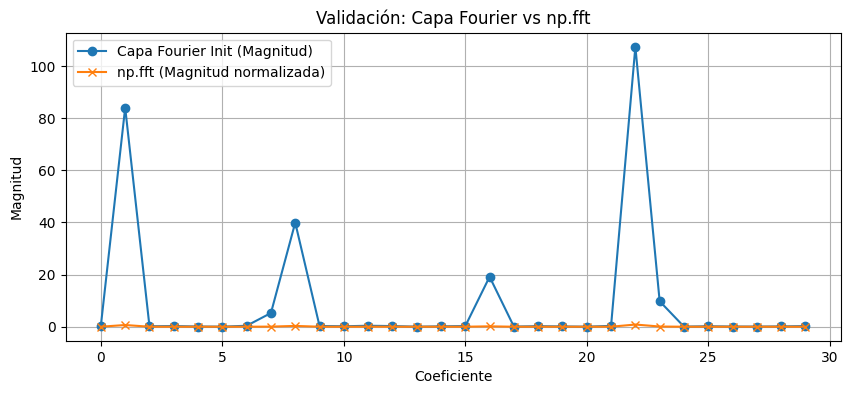

In [2]:
# Parámetros del enunciado
N = 256
K = 15

# Vector de tiempo discreto normalizado [0, 1)
t = jnp.linspace(0, 1, N, endpoint=False)

# Construcción de W1 (Fourier Init)
# Filas de senos y cosenos para k = 1, 2, ..., 15
cosinos = jnp.cos(2 * jnp.pi * jnp.arange(1, K+1)[:, None] * t[None, :]) # Shape (15, 256)
senos = jnp.sin(2 * jnp.pi * jnp.arange(1, K+1)[:, None] * t[None, :])   # Shape (15, 256)
W1_fourier = jnp.vstack([cosinos, senos]) # Shape (30, 256)

# Validación: Comparar con FFT de una señal de ejemplo
senal_test = X[0]

# Salida de nuestra capa Fourier sin entrenar (sin tanh todavía, solo la base)
fourier_layer_out = jnp.dot(W1_fourier, senal_test)

# FFT de numpy (nos quedamos con las primeras 15 frecuencias positivas, reales e imaginarias)
fft_numpy = np.fft.fft(senal_test)
fft_re = fft_numpy[1:K+1].real
fft_im = fft_numpy[1:K+1].imag
fft_numpy_out = np.concatenate([fft_re, fft_im]) * (2/N) # Normalización típica

# Gráfica de validación
plt.figure(figsize=(10, 4))
plt.plot(np.abs(fourier_layer_out), 'o-', label='Capa Fourier Init (Magnitud)')
plt.plot(np.abs(fft_numpy_out), 'x-', label='np.fft (Magnitud normalizada)')
plt.xlabel('Coeficiente')
plt.ylabel('Magnitud')
plt.title('Validación: Capa Fourier vs np.fft')
plt.legend()
plt.grid(True)
plt.show()

Definir la Red y Entrenamiento

In [3]:
def init_params(key, init_type='fourier'):
    if init_type == 'fourier':
        W1 = W1_fourier
    else: # Aleatoria
        W1 = jax.random.normal(key, (2*K, N)) * 0.01
    
    # W2 se inicializa aleatoria en ambos casos
    W2 = jax.random.normal(key, (N, 2*K)) * 0.01
    return [W1, W2]

def predict(params, x):
    W1, W2 = params
    h = jnp.tanh(jnp.dot(W1, x))
    return jnp.dot(W2, h)

# Vectorización para procesar lotes
batched_predict = jax.vmap(predict, in_axes=(None, 0))

def loss_fn(params, X_batch):
    X_hat = batched_predict(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

# Gradientes
grad_fn = jax.value_and_grad(loss_fn)

def train(X_train, init_type, epochs=2000, lr=0.1):
    key = jax.random.PRNGKey(42)
    params = init_params(key, init_type)
    history_loss = []
    
    for i in range(epochs):
        loss_val, grads = grad_fn(params, X_train)
        history_loss.append(loss_val)
        
        # Actualización SGD
        params = [p - lr * g for p, g in zip(params, grads)]
        
    return params, history_loss

# Entrenar con todos los datos para ambas inicializaciones
print("Entrenando con inicialización Fourier...")
params_fourier, loss_fourier = train(X, 'fourier')
print("Entrenando con inicialización Aleatoria...")
params_random, loss_random = train(X, 'random')

Entrenando con inicialización Fourier...
Entrenando con inicialización Aleatoria...


Gráficas de comparación

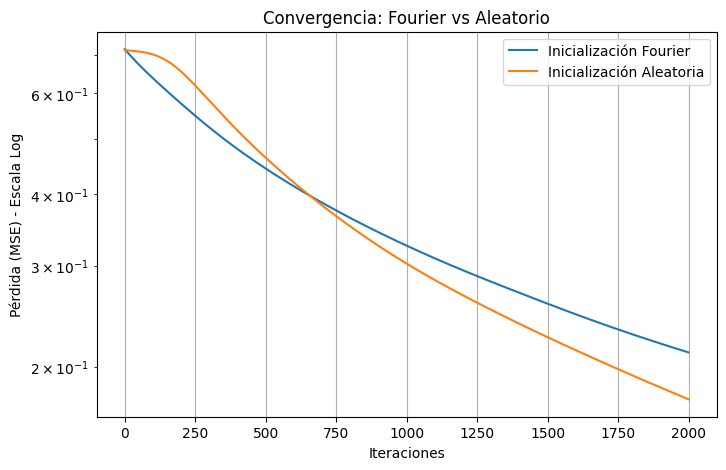

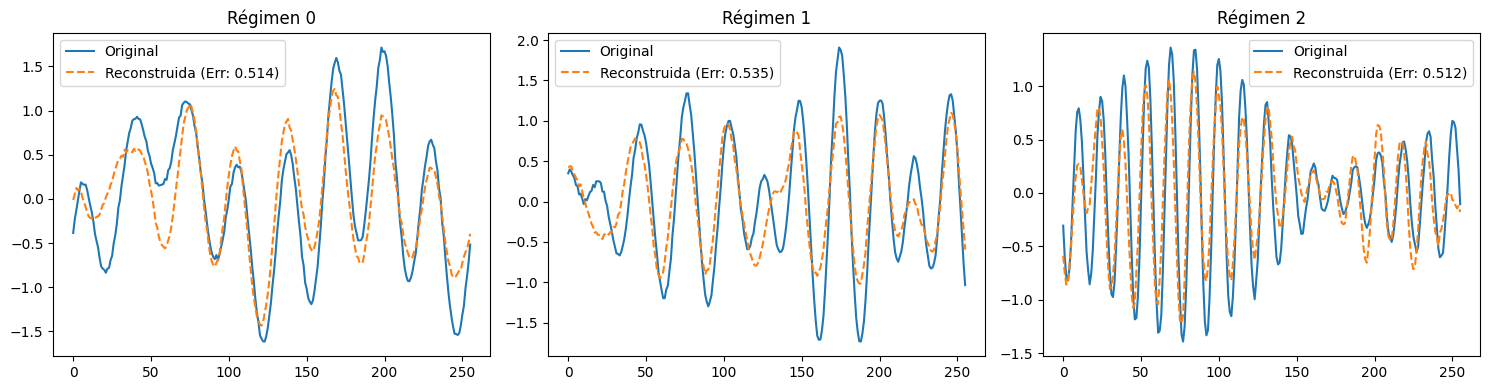

In [4]:
# 1. Curvas de pérdida superpuestas
plt.figure(figsize=(8, 5))
plt.plot(loss_fourier, label='Inicialización Fourier')
plt.plot(loss_random, label='Inicialización Aleatoria')
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE) - Escala Log')
plt.title('Convergencia: Fourier vs Aleatorio')
plt.legend()
plt.grid(True)
plt.show()

# 2. Iteraciones para error relativo < 0.1 
# (Aquí debes calcular el error relativo por época, esto es un approach aproximado basado en el loss)
# Te dejo esta tarea: iterar sobre loss_fourier/random y encontrar el índice donde baja del umbral.

# 3. Gráfica de reconstrucción (Una señal por régimen)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
regimenes = [0, 1, 2] # Ajusta si tus etiquetas son diferentes

for i, reg in enumerate(regimenes):
    idx = np.where(y_np == reg)[0][0] # Tomar la primera señal de ese régimen
    x_real = X[idx]
    x_hat = predict(params_fourier, x_real)
    
    error_relativo = jnp.linalg.norm(x_hat - x_real) / jnp.linalg.norm(x_real)
    
    axes[i].plot(x_real, label='Original')
    axes[i].plot(x_hat, '--', label=f'Reconstruida (Err: {error_relativo:.3f})')
    axes[i].set_title(f'Régimen {reg}')
    axes[i].legend()

plt.tight_layout()
plt.show()

Compresión

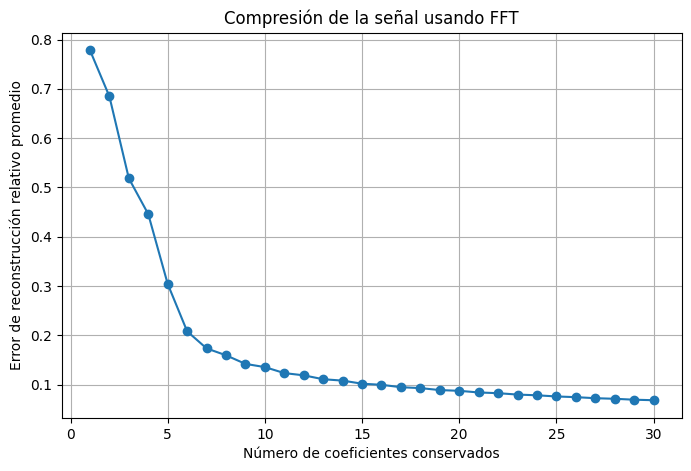

Coeficientes necesarios en promedio para 85% de energía: 5.2


In [5]:
def compresion_fourier(senal, umbral_energia=0.85):
    # Calcular FFT
    fft_s = np.fft.fft(senal)
    # Magnitud al cuadrado (energía por coeficiente)
    potencia = np.abs(fft_s)**2
    energia_total = potencia.sum()
    
    # Ordenar de mayor a menor potencia (ignorando la componente DC si quieres, índice 0)
    potencia_ordenada = np.sort(potencia)[::-1]
    
    # Energía acumulada
    energia_acum = np.cumsum(potencia_ordenada) / energia_total
    
    # Encontrar cuántos coeficientes bastan
    n_coef = np.argmax(energia_acum >= umbral_energia) + 1
    return n_coef, energia_acum

# Aplicar a todas las señales y calcular errores
n_coefs = []
errores = []
max_coef = 30 # Evaluemos hasta 30 coeficientes

for n in range(1, max_coef + 1):
    errores_n = []
    for senal in X_np:
        fft_s = np.fft.fft(senal)
        # Zer out los coeficientes que no vamos a conservar
        indices = np.argsort(np.abs(fft_s))[::-1][n:]
        fft_comprimida = fft_s.copy()
        fft_comprimida[indices] = 0
        # Reconstruir
        x_rec = np.fft.ifft(fft_comprimida).real
        # Error relativo
        err = np.linalg.norm(x_rec - senal) / np.linalg.norm(senal)
        errores_n.append(err)
    errores.append(np.mean(errores_n))

# Graficar Error vs Número de Coeficientes
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_coef+1), errores, 'o-')
plt.xlabel('Número de coeficientes conservados')
plt.ylabel('Error de reconstrucción relativo promedio')
plt.title('Compresión de la señal usando FFT')
plt.grid(True)
plt.show()

# Calcular coeficientes para 85% de energía
coefs_85 = [compresion_fourier(s)[0] for s in X_np]
print(f"Coeficientes necesarios en promedio para 85% de energía: {np.mean(coefs_85):.1f}")